# Code for STA 141C Final Project

## Data Exploration + Preprocessing

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [175]:
heart_df = pd.read_csv("heart_disease_uci.csv")

heart_df["target_binary"] = (heart_df["num"] > 0).astype(int)

heart_df = heart_df.drop(columns=["num", "id"])

heart_df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target_binary
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [176]:
print("Shape:", heart_df.shape)

print("\nData Types:")

print(heart_df.dtypes)

print("\nMissing Values:")

print(heart_df.isnull().sum())

Shape: (920, 15)

Data Types:
age                int64
sex               object
dataset           object
cp                object
trestbps         float64
chol             float64
fbs               object
restecg           object
thalch           float64
exang             object
oldpeak          float64
slope             object
ca               float64
thal              object
target_binary      int64
dtype: object

Missing Values:
age                0
sex                0
dataset            0
cp                 0
trestbps          59
chol              30
fbs               90
restecg            2
thalch            55
exang             55
oldpeak           62
slope            309
ca               611
thal             486
target_binary      0
dtype: int64


In [177]:
cleveland_df = heart_df[heart_df["dataset"] == "Cleveland"].copy()

cleveland_df = cleveland_df.drop(columns=["dataset"])

cleveland_df.isnull().sum()

age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalch           0
exang            0
oldpeak          0
slope            1
ca               5
thal             3
target_binary    0
dtype: int64

In [178]:
cleveland_df = cleveland_df.dropna()

Filtered only to Cleveland due to large amount of missing values for some variables

## Exploratory Data Analysis

In [179]:
class_counts = cleveland_df["target_binary"].value_counts()
class_percent = cleveland_df["target_binary"].value_counts(normalize=True)

print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", class_percent)

Class Counts:
 target_binary
0    160
1    137
Name: count, dtype: int64

Class Percentages:
 target_binary
0    0.538721
1    0.461279
Name: proportion, dtype: float64


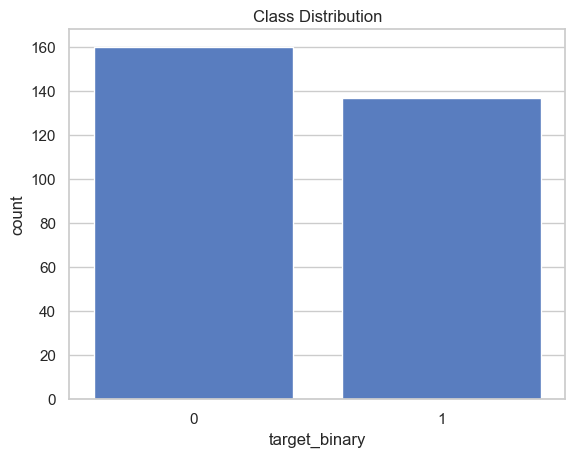

In [180]:
sns.set_theme(style="whitegrid", palette="muted")

sns.countplot(x="target_binary", data=cleveland_df)
plt.title("Class Distribution")
plt.show()

In [181]:
numerical_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print(cleveland_df[numerical_features].describe())

              age    trestbps        chol      thalch     oldpeak
count  297.000000  297.000000  297.000000  297.000000  297.000000
mean    54.542088  131.693603  247.350168  149.599327    1.055556
std      9.049736   17.762806   51.997583   22.941562    1.166123
min     29.000000   94.000000  126.000000   71.000000    0.000000
25%     48.000000  120.000000  211.000000  133.000000    0.000000
50%     56.000000  130.000000  243.000000  153.000000    0.800000
75%     61.000000  140.000000  276.000000  166.000000    1.600000
max     77.000000  200.000000  564.000000  202.000000    6.200000


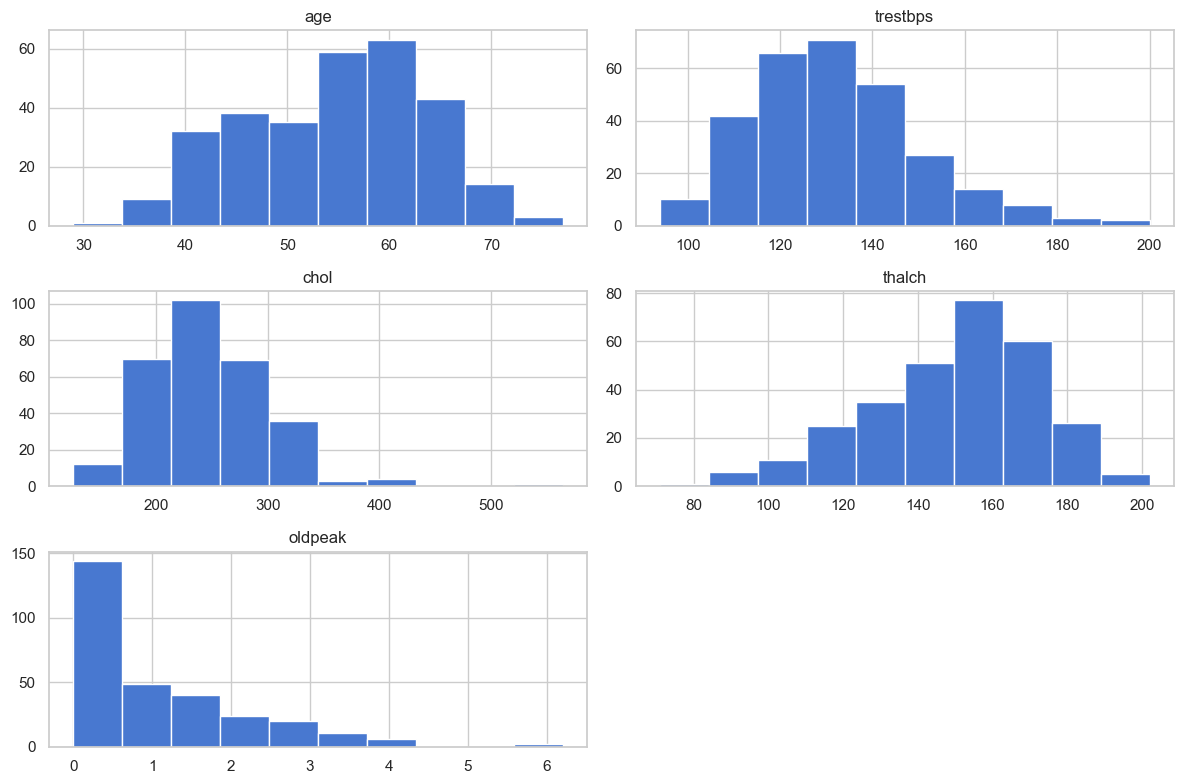

In [182]:
cleveland_df[numerical_features].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

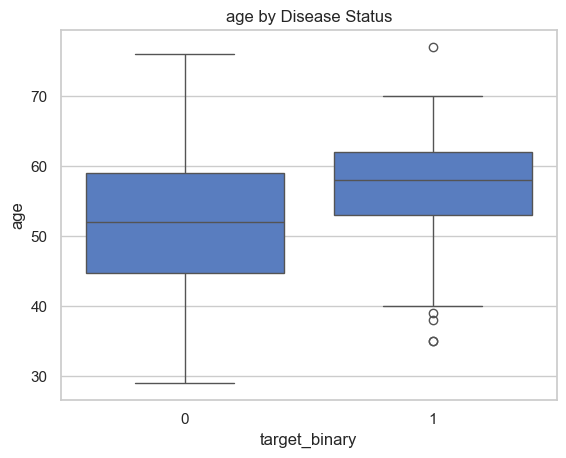

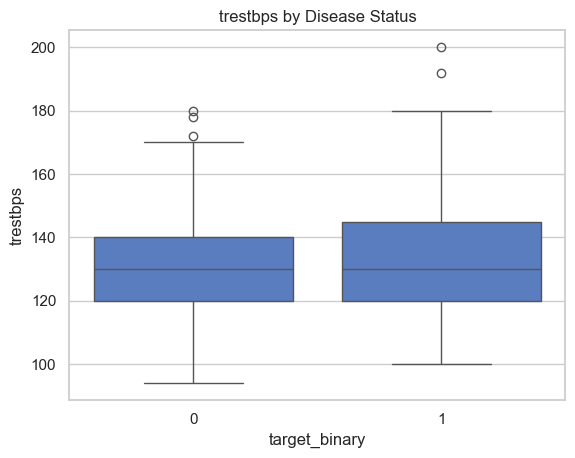

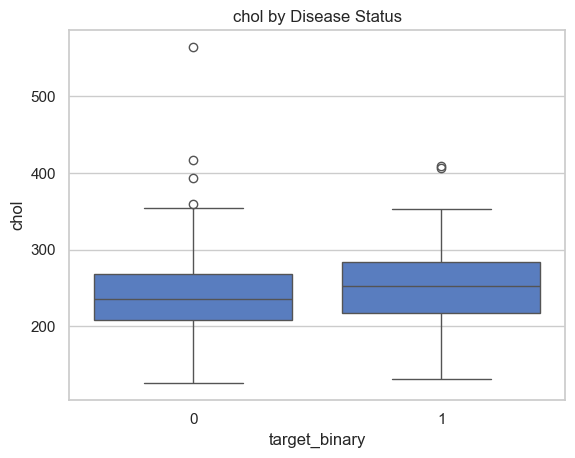

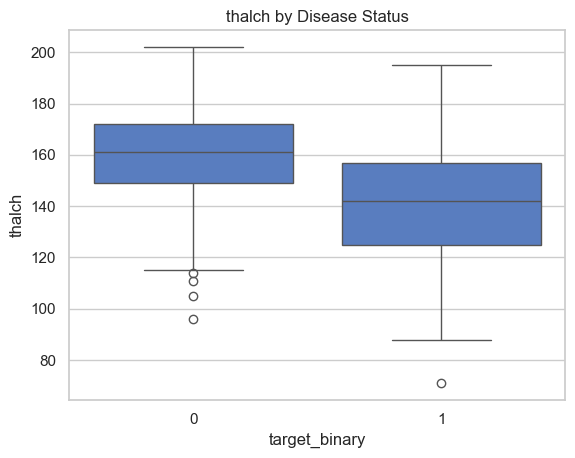

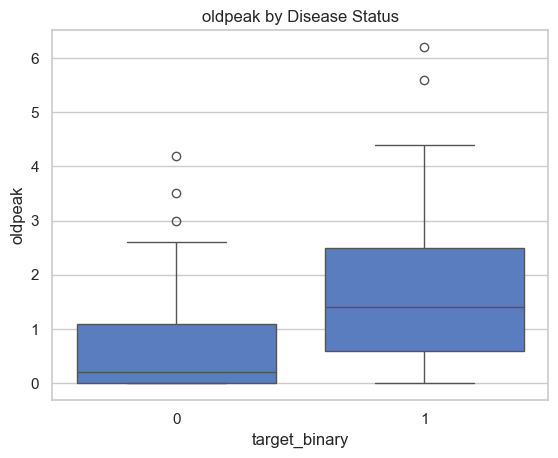

In [183]:
for col in numerical_features:
    plt.figure()
    sns.boxplot(x="target_binary", y=col, data=cleveland_df)
    plt.title(f"{col} by Disease Status")
    plt.show()

In [184]:
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    print(cleveland_df[col].value_counts())


Value counts for sex:
sex
Male      201
Female     96
Name: count, dtype: int64

Value counts for cp:
cp
asymptomatic       142
non-anginal         83
atypical angina     49
typical angina      23
Name: count, dtype: int64

Value counts for fbs:
fbs
False    254
True      43
Name: count, dtype: int64

Value counts for restecg:
restecg
normal              147
lv hypertrophy      146
st-t abnormality      4
Name: count, dtype: int64

Value counts for exang:
exang
False    200
True      97
Name: count, dtype: int64

Value counts for slope:
slope
upsloping      139
flat           137
downsloping     21
Name: count, dtype: int64

Value counts for ca:
ca
0.0    174
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

Value counts for thal:
thal
normal               164
reversable defect    115
fixed defect          18
Name: count, dtype: int64


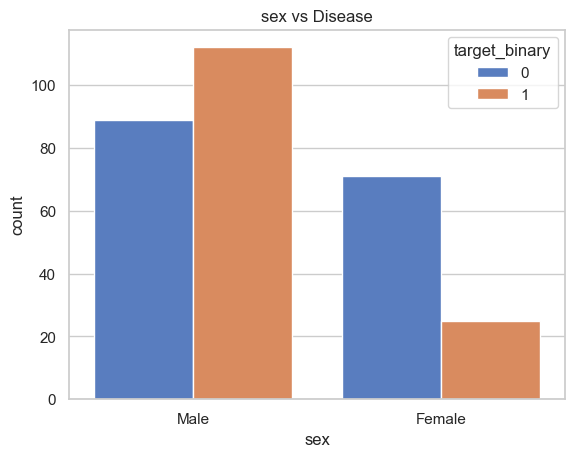

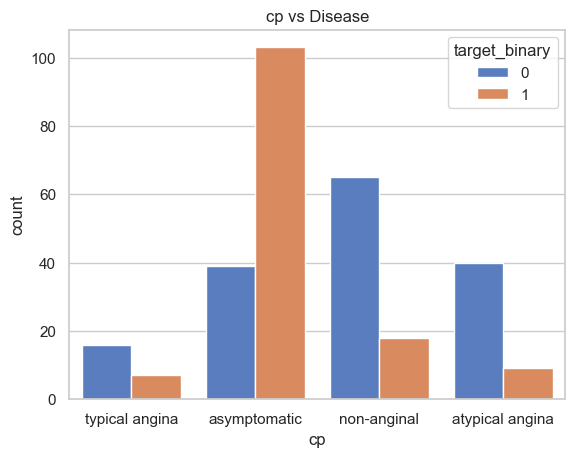

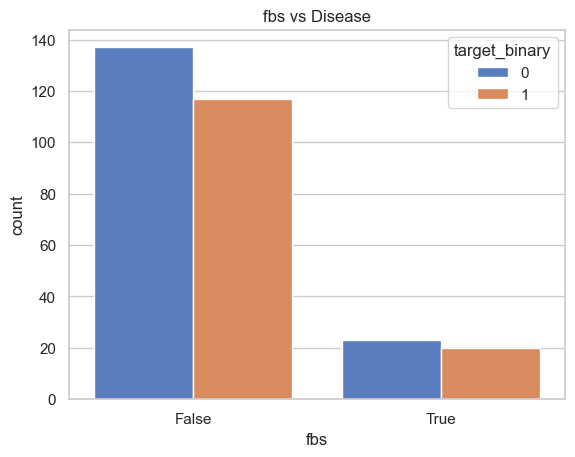

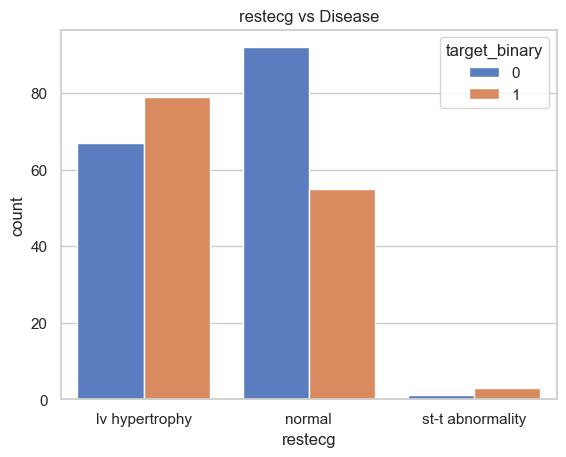

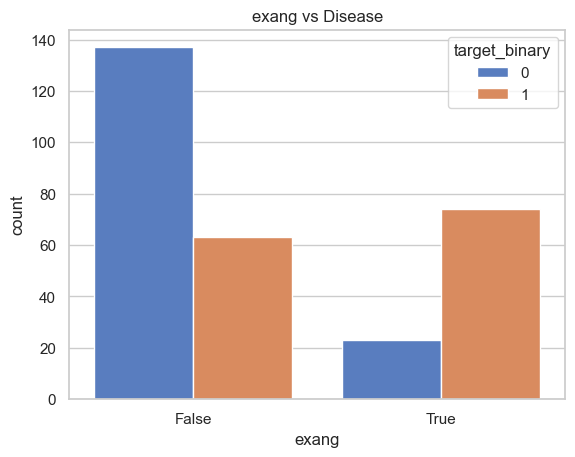

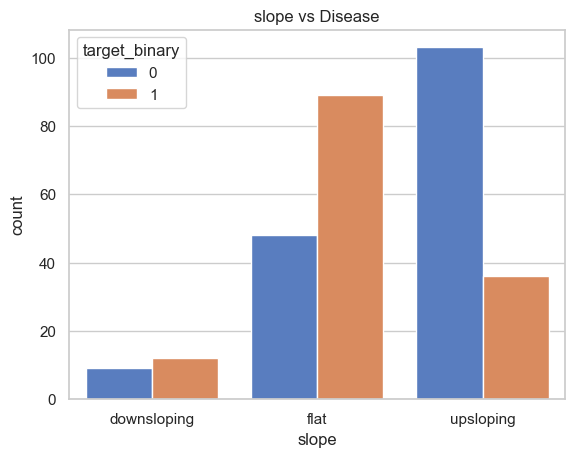

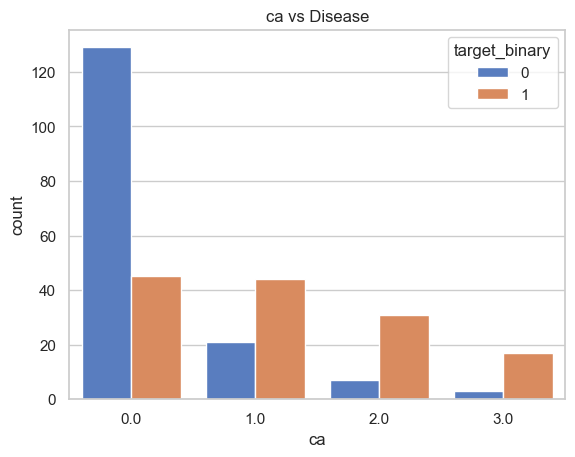

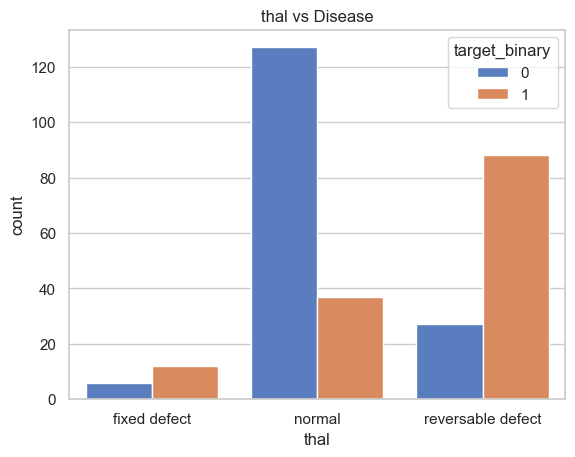

In [185]:
for col in categorical_features:
    plt.figure()
    sns.countplot(x=col, hue="target_binary", data=cleveland_df)
    plt.title(f"{col} vs Disease")
    plt.show()

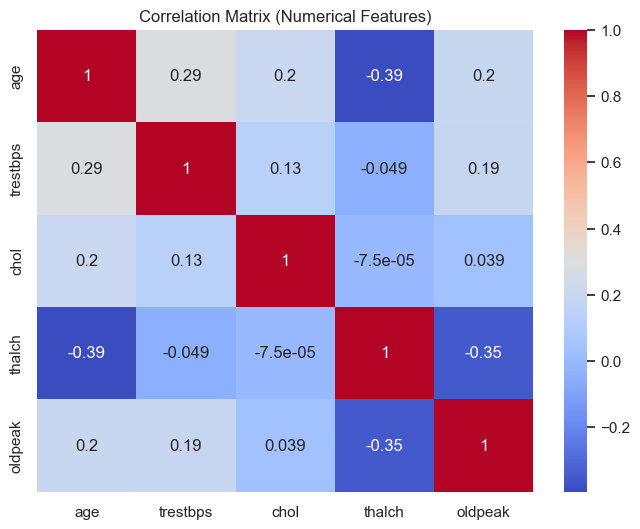

In [186]:
plt.figure(figsize=(8,6))
sns.heatmap(cleveland_df[numerical_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

In [187]:
cleveland_df_num = pd.get_dummies(cleveland_df, drop_first=True)
cleveland_df_num = cleveland_df_num.astype(float)

print(cleveland_df_num.dtypes)

age                         float64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
target_binary               float64
sex_Male                    float64
cp_atypical angina          float64
cp_non-anginal              float64
cp_typical angina           float64
fbs_True                    float64
restecg_normal              float64
restecg_st-t abnormality    float64
exang_True                  float64
slope_flat                  float64
slope_upsloping             float64
thal_normal                 float64
thal_reversable defect      float64
dtype: object


In [188]:
corr_with_target = cleveland_df_num.corr()["target_binary"].sort_values(ascending=False)
print(corr_with_target)

target_binary               1.000000
thal_reversable defect      0.484657
ca                          0.463189
oldpeak                     0.424052
exang_True                  0.421355
slope_flat                  0.349635
sex_Male                    0.278467
age                         0.227075
trestbps                    0.153490
chol                        0.080285
restecg_st-t abnormality    0.067672
fbs_True                    0.003167
cp_typical angina          -0.091208
restecg_normal             -0.173028
cp_atypical angina         -0.247535
cp_non-anginal             -0.305345
slope_upsloping            -0.380612
thalch                     -0.423817
thal_normal                -0.524972
Name: target_binary, dtype: float64


In [189]:
X = cleveland_df.drop(columns=["target_binary"])
y = cleveland_df["target_binary"]

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

print(X.dtypes)

age                         float64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
sex_Male                    float64
cp_atypical angina          float64
cp_non-anginal              float64
cp_typical angina           float64
fbs_True                    float64
restecg_normal              float64
restecg_st-t abnormality    float64
exang_True                  float64
slope_flat                  float64
slope_upsloping             float64
thal_normal                 float64
thal_reversable defect      float64
dtype: object


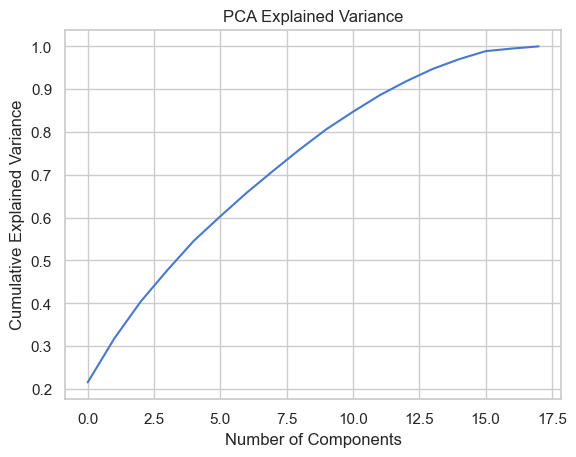

In [190]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [191]:
X_vif = pd.DataFrame(X_scaled, columns=X.columns)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                     Feature       VIF
0                        age  1.502780
1                   trestbps  1.226644
2                       chol  1.150616
3                     thalch  1.735684
4                    oldpeak  1.866709
5                         ca  1.377499
6                   sex_Male  1.342241
7         cp_atypical angina  1.505768
8             cp_non-anginal  1.513534
9          cp_typical angina  1.242780
10                  fbs_True  1.127052
11            restecg_normal  1.121490
12  restecg_st-t abnormality  1.076907
13                exang_True  1.434947
14                slope_flat  4.840304
15           slope_upsloping  5.907568
16               thal_normal  5.491236
17    thal_reversable defect  4.795685


Since there are very few predictors, this indicates mild to moderate multicollinearity and motivates use of ridge.

In [192]:
pd.DataFrame(X_scaled).to_csv("X_processed.csv", index=False)
pd.Series(y, name="target").to_csv("y_processed.csv", index=False)

print("Saved X_processed.csv and y_processed.csv")

Saved X_processed.csv and y_processed.csv


## Dimensionality Reduction with PCA

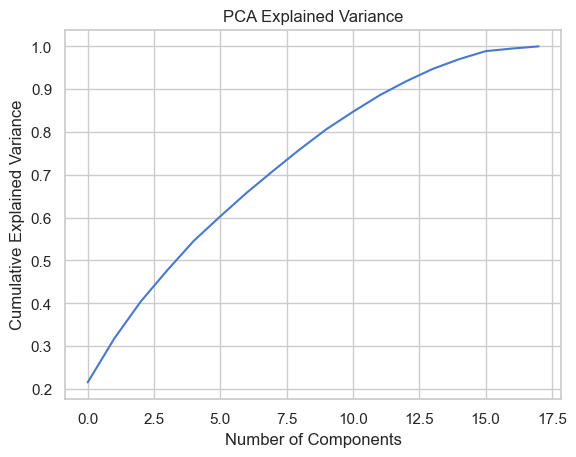

Selected k values: [2, 5, np.int64(13), np.int64(15)]
k_90: 13 k_95: 15


In [193]:
from sklearn.decomposition import PCA

# Fit PCA to the full dataset
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = np.cumsum(pca_full.explained_variance_ratio_)

import matplotlib.pyplot as plt
plt.plot(explained)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find k for 90% and 95% variance
k_90 = np.argmax(explained_variance >= 0.90) + 1
k_95 = np.argmax(explained_variance >= 0.95) + 1

k_values = sorted(set([2, 5, k_90, k_95]))

print("Selected k values:", k_values)
print("k_90:", k_90, "k_95:", k_95)

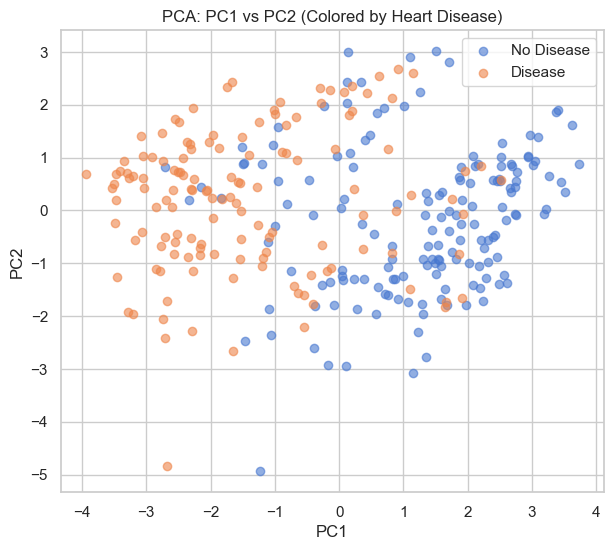

In [194]:
# PCA Visualization: PC1 vs PC2 Scatter Plot by Heart Disease Status

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA with 2 components
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

# PC1 vs PC2
plt.figure(figsize=(7,6))

plt.scatter(
    X_pca_2[y_arr == 0, 0],
    X_pca_2[y_arr == 0, 1],
    alpha=0.6,
    label="No Disease"
)

plt.scatter(
    X_pca_2[y_arr == 1, 0],
    X_pca_2[y_arr == 1, 1],
    alpha=0.6,
    label="Disease"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2 (Colored by Heart Disease)")
plt.legend()
plt.grid(True)
plt.show()

In [195]:
# Interpretation of Principal Components with Feature Loadings

feature_names = X.columns

loadings = pca_2.components_.T

loadings_df = pd.DataFrame(
    loadings,
    columns=["PC1", "PC2"],
    index=feature_names
)

# Add absolute values for ranking
loadings_df["Abs_PC1"] = np.abs(loadings_df["PC1"])
loadings_df["Abs_PC2"] = np.abs(loadings_df["PC2"])

# Top variables for PC1
top_pc1 = loadings_df.sort_values("Abs_PC1", ascending=False).head(10)

# Top variables for PC2
top_pc2 = loadings_df.sort_values("Abs_PC2", ascending=False).head(10)

print("Top variables for PC1:")
display(top_pc1[["PC1", "Abs_PC1"]])

print("\nTop variables for PC2:")
display(top_pc2[["PC2", "Abs_PC2"]])

Top variables for PC1:


,PC1,Abs_PC1
slope_upsloping,0.367391,0.367391
thal_normal,0.356518,0.356518
oldpeak,-0.337245,0.337245
thalch,0.333317,0.333317
slope_flat,-0.330619,0.330619
thal_reversable defect,-0.320223,0.320223
exang_True,-0.279043,0.279043
ca,-0.239555,0.239555
age,-0.217340,0.217340
cp_atypical angina,0.216176,0.216176



Top variables for PC2:


,PC2,Abs_PC2
sex_Male,0.481341,0.481341
thal_reversable defect,0.405789,0.405789
thal_normal,-0.393628,0.393628
age,-0.323754,0.323754
chol,-0.269659,0.269659
restecg_normal,0.234248,0.234248
restecg_st-t abnormality,-0.224122,0.224122
trestbps,-0.186903,0.186903
slope_flat,-0.167940,0.167940
slope_upsloping,0.167632,0.167632


## Logistic Regression Modeling

### Baseline Logistic Regression

In [196]:
# Baseline Predictive Model - Logistic Regression with 5-Fold Cross-Validation

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score

def cv_logistic_baseline(X_scaled, y, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    aucs, accs, fit_times = [], [], []

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr), start=1):
        X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
        y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

        model = LogisticRegression(
            C=1e12,         
            solver="lbfgs",
            max_iter=5000
        )

        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        t1 = time.perf_counter()

        p_va = model.predict_proba(X_va)[:, 1]
        yhat_va = (p_va >= 0.5).astype(int)

        auc = roc_auc_score(y_va, p_va)
        acc = accuracy_score(y_va, yhat_va)

        aucs.append(auc)
        accs.append(acc)
        fit_times.append(t1 - t0)

        print(f"Fold {fold}: AUC={auc:.4f}, Acc={acc:.4f}, FitTime={t1-t0:.4f}s")

    print("\n=== 5-Fold CV Summary (Baseline Logistic) ===")
    print(f"AUC: {np.mean(aucs):.4f} ± {np.std(aucs, ddof=1):.4f}")
    print(f"Acc: {np.mean(accs):.4f} ± {np.std(accs, ddof=1):.4f}")
    print(f"Fit time: {np.mean(fit_times):.4f}s ± {np.std(fit_times, ddof=1):.4f}s")

    return {
        "AUC_mean": float(np.mean(aucs)),
        "AUC_std": float(np.std(aucs, ddof=1)),
        "Acc_mean": float(np.mean(accs)),
        "Acc_std": float(np.std(accs, ddof=1)),
        "FitTime_mean_sec": float(np.mean(fit_times)),
        "FitTime_std_sec": float(np.std(fit_times, ddof=1)),
        "AUCs": aucs,
        "Accs": accs,
        "FitTimes_sec": fit_times
    }

baseline_results = cv_logistic_baseline(X_scaled, y, n_splits=5, random_state=42)

Fold 1: AUC=0.9386, Acc=0.9000, FitTime=0.0022s
Fold 2: AUC=0.8705, Acc=0.7833, FitTime=0.0013s
Fold 3: AUC=0.8322, Acc=0.7627, FitTime=0.0014s
Fold 4: AUC=0.8646, Acc=0.8305, FitTime=0.0010s
Fold 5: AUC=0.9375, Acc=0.8305, FitTime=0.0009s

=== 5-Fold CV Summary (Baseline Logistic) ===
AUC: 0.8887 ± 0.0474
Acc: 0.8214 ± 0.0530
Fit time: 0.0014s ± 0.0005s


### Ridge

In [197]:
# Regularized Logistic Regression (Ridge) - Hyperparameter Tuning with Cross-Validation

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score


def cv_ridge_logistic(X_scaled, y, C_values, n_splits=5, random_state=42):

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    results = []

    for C in C_values:

        aucs, accs, times = [], [], []

        for train_idx, val_idx in skf.split(X_scaled, y_arr):

            X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
            y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

            model = LogisticRegression(
                C=C,
                solver="lbfgs",
                max_iter=5000
            )

            t0 = time.perf_counter()
            model.fit(X_tr, y_tr)
            t1 = time.perf_counter()

            p = model.predict_proba(X_va)[:, 1]
            yhat = (p >= 0.5).astype(int)

            aucs.append(roc_auc_score(y_va, p))
            accs.append(accuracy_score(y_va, yhat))
            times.append(t1 - t0)

        results.append({
            "C": C,
            "AUC_mean": np.mean(aucs),
            "AUC_std": np.std(aucs, ddof=1),
            "Acc_mean": np.mean(accs),
            "Acc_std": np.std(accs, ddof=1),
            "FitTime_mean": np.mean(times)
        })

        print(f"C={C}: AUC={np.mean(aucs):.4f}")

    return results


C_grid = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_results = cv_ridge_logistic(X_scaled, y, C_grid)

ridge_results

C=0.001: AUC=0.9058
C=0.01: AUC=0.9072
C=0.1: AUC=0.9014
C=1: AUC=0.8948
C=10: AUC=0.8927
C=100: AUC=0.8909
C=1000: AUC=0.8889


[{'C': 0.001,
  'AUC_mean': np.float64(0.9057953042328043),
  'AUC_std': np.float64(0.0405957615597085),
  'Acc_mean': np.float64(0.7944632768361581),
  'Acc_std': np.float64(0.04247896325543879),
  'FitTime_mean': np.float64(0.0009082500007934868)},
 {'C': 0.01,
  'AUC_mean': np.float64(0.9071593915343916),
  'AUC_std': np.float64(0.04277233294346362),
  'Acc_mean': np.float64(0.8315819209039548),
  'Acc_std': np.float64(0.058672935211314274),
  'FitTime_mean': np.float64(0.0006259747955482453)},
 {'C': 0.1,
  'AUC_mean': np.float64(0.901397156084656),
  'AUC_std': np.float64(0.04887501532192524),
  'Acc_mean': np.float64(0.8415819209039548),
  'Acc_std': np.float64(0.06667606225087855),
  'FitTime_mean': np.float64(0.0005545083957258611)},
 {'C': 1,
  'AUC_mean': np.float64(0.8947503306878307),
  'AUC_std': np.float64(0.04862738618579988),
  'Acc_mean': np.float64(0.8280790960451977),
  'Acc_std': np.float64(0.04895798888373823),
  'FitTime_mean': np.float64(0.0006850250065326691)},


### Lasso

In [198]:
# Regularized Logistic Regression (Lasso) - Feature Selection with L1 Penalty

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


def cv_lasso_logistic(X_scaled, y, C_values, n_splits=5, random_state=42):

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    results = []

    for C in C_values:

        aucs, accs, times, n_nonzero = [], [], [], []

        for train_idx, val_idx in skf.split(X_scaled, y_arr):

            X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
            y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

            model = LogisticRegression(
                penalty="l1",
                C=C,
                solver="liblinear",   # required for L1
                max_iter=5000
            )

            t0 = time.perf_counter()
            model.fit(X_tr, y_tr)
            t1 = time.perf_counter()

            p = model.predict_proba(X_va)[:, 1]
            yhat = (p >= 0.5).astype(int)

            aucs.append(roc_auc_score(y_va, p))
            accs.append(accuracy_score(y_va, yhat))
            times.append(t1 - t0)

            # Count the number of selected features
            n_nonzero.append(np.sum(model.coef_ != 0))

        results.append({
            "C": C,
            "AUC_mean": np.mean(aucs),
            "AUC_std": np.std(aucs, ddof=1),
            "Acc_mean": np.mean(accs),
            "Acc_std": np.std(accs, ddof=1),
            "FitTime_mean": np.mean(times),
            "Num_Selected_mean": np.mean(n_nonzero)
        })

        print(f"C={C}: AUC={np.mean(aucs):.4f}, Selected={np.mean(n_nonzero):.1f}")

    return results


C_grid_lasso = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

lasso_results = cv_lasso_logistic(X_scaled, y, C_grid_lasso)

lasso_results

C=0.001: AUC=0.5000, Selected=0.0
C=0.01: AUC=0.5000, Selected=0.0
C=0.05: AUC=0.8909, Selected=8.0
C=0.1: AUC=0.8947, Selected=11.6
C=0.5: AUC=0.8968, Selected=15.4
C=1: AUC=0.8963, Selected=16.8
C=5: AUC=0.8931, Selected=17.4
C=10: AUC=0.8932, Selected=17.6


[{'C': 0.001,
  'AUC_mean': np.float64(0.5),
  'AUC_std': np.float64(0.0),
  'Acc_mean': np.float64(0.4612429378531074),
  'Acc_std': np.float64(0.004951164361628623),
  'FitTime_mean': np.float64(0.00048752500442788004),
  'Num_Selected_mean': np.float64(0.0)},
 {'C': 0.01,
  'AUC_mean': np.float64(0.5),
  'AUC_std': np.float64(0.0),
  'Acc_mean': np.float64(0.4612429378531074),
  'Acc_std': np.float64(0.004951164361628623),
  'FitTime_mean': np.float64(0.00028005820349790155),
  'Num_Selected_mean': np.float64(0.0)},
 {'C': 0.05,
  'AUC_mean': np.float64(0.8908647486772487),
  'AUC_std': np.float64(0.0436610324992702),
  'Acc_mean': np.float64(0.8115254237288136),
  'Acc_std': np.float64(0.04804560764848976),
  'FitTime_mean': np.float64(0.0004239331930875778),
  'Num_Selected_mean': np.float64(8.0)},
 {'C': 0.1,
  'AUC_mean': np.float64(0.8946593915343917),
  'AUC_std': np.float64(0.05036867977862143),
  'Acc_mean': np.float64(0.807909604519774),
  'Acc_std': np.float64(0.0586537553

In [199]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

best_C = 0.5

best_lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=best_C,
    max_iter=5000
)

best_lasso.fit(X_scaled, y)

feature_names = X.columns

coef = best_lasso.coef_[0]

lasso_features = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

# Keep only selected features 
lasso_selected = lasso_features[lasso_features["Coefficient"] != 0]

lasso_selected = lasso_selected.reindex(
    lasso_selected["Coefficient"].abs().sort_values(ascending=False).index
)

print("Selected Features by Lasso:\n")
print(lasso_selected)

print("\nNumber of selected features:", len(lasso_selected))

Selected Features by Lasso:

                   Feature  Coefficient
5                       ca     1.014652
8           cp_non-anginal    -0.679030
17  thal_reversable defect     0.589156
6                 sex_Male     0.534987
9        cp_typical angina    -0.433714
4                  oldpeak     0.389094
13              exang_True     0.315329
3                   thalch    -0.314684
1                 trestbps     0.284910
14              slope_flat     0.264538
7       cp_atypical angina    -0.247909
15         slope_upsloping    -0.192067
11          restecg_normal    -0.184223
2                     chol     0.114386
10                fbs_True    -0.109471
16             thal_normal    -0.061423

Number of selected features: 16


### Logistic Regression on PCA-Reduced Data

In [200]:
# Logistic Regression on PCA-Reduced Data

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.decomposition import PCA
import numpy as np
import time


def cv_pca_logistic(X_scaled, y, k, n_splits=5, random_state=42):

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    aucs, accs, times = [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr), start=1):

        X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
        y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

        # Fit PCA on training fold only
        pca = PCA(n_components=k)
        X_tr_pca = pca.fit_transform(X_tr)
        X_va_pca = pca.transform(X_va)

        model = LogisticRegression(
            C=1e12,
            solver="lbfgs",
            max_iter=5000
        )

        t0 = time.perf_counter()
        model.fit(X_tr_pca, y_tr)
        t1 = time.perf_counter()

        p = model.predict_proba(X_va_pca)[:, 1]
        yhat = (p >= 0.5).astype(int)

        aucs.append(roc_auc_score(y_va, p))
        accs.append(accuracy_score(y_va, yhat))
        times.append(t1 - t0)

    return {
        "AUC_mean": np.mean(aucs),
        "AUC_std": np.std(aucs, ddof=1),
        "Acc_mean": np.mean(accs),
        "Acc_std": np.std(accs, ddof=1),
        "FitTime_mean": np.mean(times)
    }

In [201]:
# Effect of PCA Dimension on Predictive Performance

k_list = [2, 5, 13, 15]

pca_results = []

for k in k_list:

    res = cv_pca_logistic(X_scaled, y, k)

    res["k"] = k

    # Explained variance for reporting
    pca = PCA(n_components=k)
    pca.fit(X_scaled)
    res["ExplainedVar"] = np.sum(pca.explained_variance_ratio_)

    pca_results.append(res)

    print(f"k={k}: AUC={res['AUC_mean']:.4f}, Var={res['ExplainedVar']:.3f}")

pd.DataFrame(pca_results)

k=2: AUC=0.8959, Var=0.318
k=5: AUC=0.9046, Var=0.546
k=13: AUC=0.8896, Var=0.918
k=15: AUC=0.8966, Var=0.970


,AUC_mean,AUC_std,Acc_mean,Acc_std,FitTime_mean,k,ExplainedVar
0,0.895866,0.036948,0.801469,0.062016,0.000587,2,0.317741
1,0.904646,0.046390,0.824859,0.057123,0.000486,5,0.546003
2,0.889633,0.045955,0.831356,0.080896,0.000645,13,0.918354
3,0.896635,0.044206,0.831525,0.045133,0.000635,15,0.970055


## Interpretation of Best Ridge Model

In [202]:
# Feature Importance via Coefficients and Odds Ratios

from sklearn.linear_model import LogisticRegression

# Fit best ridge model on full data
ridge_best = LogisticRegression(
    C=0.01,
    solver="lbfgs",
    max_iter=5000
)

ridge_best.fit(X_scaled, y)

feature_names = X.columns

coef = ridge_best.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef,
    "Odds_Ratio": np.exp(coef)
})

# Sort by absolute effect
coef_df["AbsCoef"] = np.abs(coef_df["Coefficient"])

coef_df_sorted = coef_df.sort_values("AbsCoef", ascending=False)

coef_df_sorted.head(10)

,Feature,Coefficient,Odds_Ratio,AbsCoef
5,ca,0.280457,1.323735,0.280457
16,thal_normal,-0.222449,0.800556,0.222449
17,thal_reversable defect,0.213903,1.238503,0.213903
8,cp_non-anginal,-0.194323,0.823392,0.194323
13,exang_True,0.193391,1.213357,0.193391
4,oldpeak,0.177029,1.193666,0.177029
3,thalch,-0.176898,0.837865,0.176898
6,sex_Male,0.163594,1.177736,0.163594
15,slope_upsloping,-0.128309,0.879582,0.128309
14,slope_flat,0.125569,1.133794,0.125569


In [203]:
# Ridge Coefficients vs PCA Loadings

comparison_df = coef_df_sorted.merge(
    loadings_df,
    left_on="Feature",
    right_index=True
)

comparison_df = comparison_df[
    ["Feature", "Coefficient", "Odds_Ratio", "PC1", "PC2"]
]

comparison_df.head(10)

,Feature,Coefficient,Odds_Ratio,PC1,PC2
5,ca,0.280457,1.323735,-0.239555,-0.076336
16,thal_normal,-0.222449,0.800556,0.356518,-0.393628
17,thal_reversable defect,0.213903,1.238503,-0.320223,0.405789
8,cp_non-anginal,-0.194323,0.823392,0.125785,-0.161710
13,exang_True,0.193391,1.213357,-0.279043,0.097568
4,oldpeak,0.177029,1.193666,-0.337245,-0.061955
3,thalch,-0.176898,0.837865,0.333317,0.126755
6,sex_Male,0.163594,1.177736,-0.120677,0.481341
15,slope_upsloping,-0.128309,0.879582,0.367391,0.167632
14,slope_flat,0.125569,1.133794,-0.330619,-0.167940


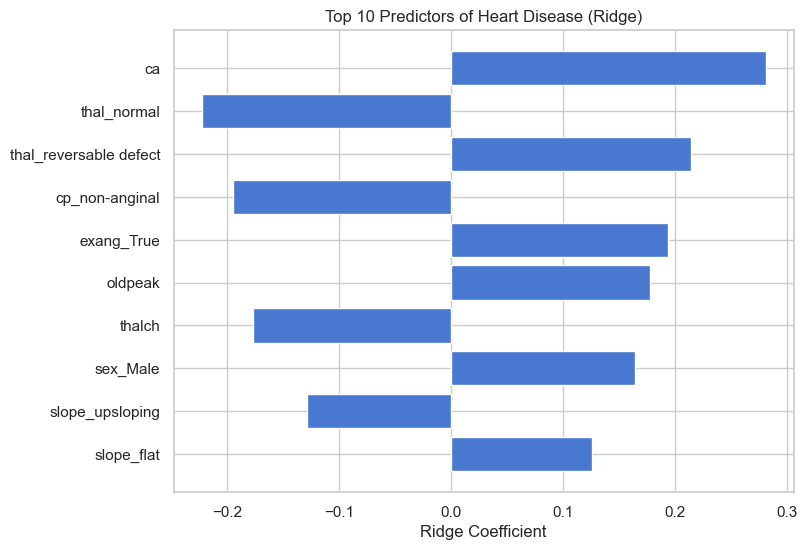

In [204]:
# Chart of Top Ridge Coefficients

import matplotlib.pyplot as plt

top10 = coef_df_sorted.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Ridge Coefficient")
plt.title("Top 10 Predictors of Heart Disease (Ridge)")
plt.show()

In [205]:
import pandas as pd
import numpy as np
import time

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.decomposition import PCA


def evaluate_model(X, y, model, model_name, n_splits=5, random_state=42):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    train_auc, test_auc = [], []
    train_acc, test_acc = [], []

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    for train_idx, test_idx in skf.split(X, y_arr):

        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y_arr[train_idx], y_arr[test_idx]

        model.fit(X_tr, y_tr)

        # TRAIN predictions
        p_tr = model.predict_proba(X_tr)[:,1]
        yhat_tr = (p_tr >= 0.5).astype(int)

        train_auc.append(roc_auc_score(y_tr, p_tr))
        train_acc.append(accuracy_score(y_tr, yhat_tr))

        # TEST predictions
        p_te = model.predict_proba(X_te)[:,1]
        yhat_te = (p_te >= 0.5).astype(int)

        test_auc.append(roc_auc_score(y_te, p_te))
        test_acc.append(accuracy_score(y_te, yhat_te))


    return {
        "Model": model_name,
        "Train AUC": np.mean(train_auc),
        "Test AUC": np.mean(test_auc),
        "Train Accuracy": np.mean(train_acc),
        "Test Accuracy": np.mean(test_acc)
    }

results = []

# Baseline logistic
baseline = LogisticRegression(C=1e12, solver="lbfgs", max_iter=5000)
results.append(evaluate_model(X_scaled, y, baseline, "Baseline Logistic"))

# Ridge logistic
ridge = LogisticRegression(C=0.01, solver="lbfgs", max_iter=5000)
results.append(evaluate_model(X_scaled, y, ridge, "Ridge Logistic"))

# Lasso logistic
lasso = LogisticRegression(penalty="l1", C=0.5, solver="liblinear", max_iter=5000)
results.append(evaluate_model(X_scaled, y, lasso, "Lasso Logistic"))

# PCA logistic
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

pca_model = LogisticRegression(C=1e12, solver="lbfgs", max_iter=5000)
results.append(evaluate_model(X_pca, y, pca_model, "Logistic + PCA (k=5)"))

results_table = pd.DataFrame(results)

results_table    

,Model,Train AUC,Test AUC,Train Accuracy,Test Accuracy
0,Baseline Logistic,0.939909,0.888682,0.875410,0.821412
1,Ridge Logistic,0.921459,0.907159,0.853523,0.831582
2,Lasso Logistic,0.937798,0.896809,0.866142,0.821356
3,Logistic + PCA (k=5),0.914128,0.904142,0.847626,0.831525
